In [1]:
pip install geopandas


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
pip install us

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.0/323.0 kB 7.8 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
pip install --upgrade nbformat


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
pip install plotly


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [39]:
pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [40]:
pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [41]:
import geopandas as gpd
import plotly.express as px
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [42]:
folder_path = "data_raw/shapefiles/historicalstates"
pre_map_df = gpd.read_file(folder_path)
pre_map_df.rename(columns={'STATENAM': 'state'}, inplace=True)

              0          1          2   3   4   5   6   7   8   9   10  11  \
0          State  Total Pop  Slave Pop NaN NaN NaN NaN NaN NaN NaN NaN NaN   
1          Maine      49133        458 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
2  New Hampshire      87802        541 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
3        Vermont      47620         50 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
4  Massachusetts     268627       4822 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
5   Rhode Island      52946       2671 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
6    Connecticut     206701       5885 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
7       New York     210541      21054 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
8     New Jersey     139627      10460 NaN NaN NaN NaN NaN NaN NaN NaN NaN   
9   Pennsylvania     327305       7855 NaN NaN NaN NaN NaN NaN NaN NaN NaN   

   12  13  14  15  16  
0 NaN NaN NaN NaN NaN  
1 NaN NaN NaN NaN NaN  
2 NaN NaN NaN NaN NaN  
3 NaN NaN NaN NaN NaN  
4 NaN NaN NaN NaN NaN

/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_3058/1819848419.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_map_df.rename(columns={'population': 'old_population'}, inplace=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_3058/1819848419.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained a

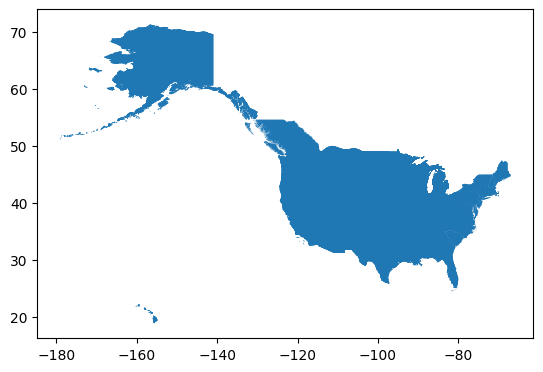

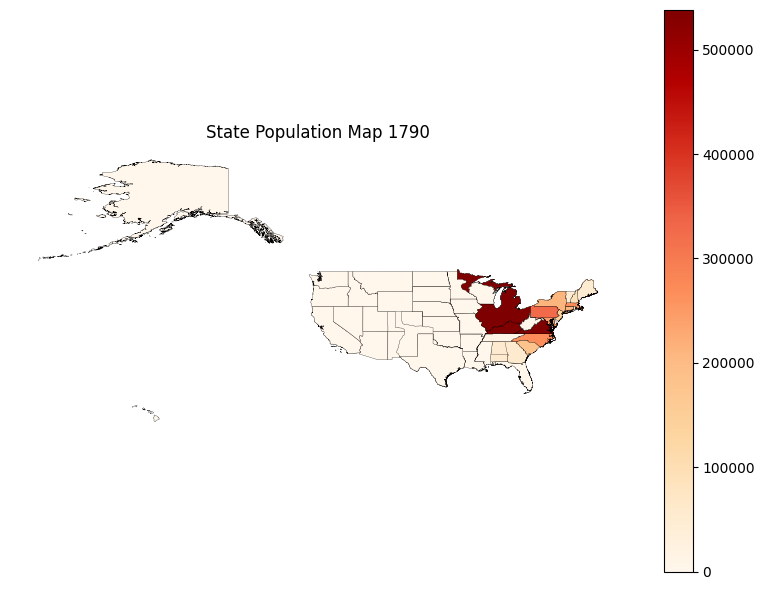

In [43]:
pre_map_df["geometry"] = pre_map_df["geometry"].simplify(0.01).buffer(0)
pre_map_df = pre_map_df.set_crs('EPSG:4326', allow_override=True)

pre_map_df.plot()
for col in pre_map_df.select_dtypes(include='datetime'):
    pre_map_df[col] = pre_map_df[col].astype(str)

pre_map_str = pre_map_df.to_json()

pre_map_gj = json.loads(pre_map_str)

state_pops_raw = pd.read_csv("data_raw/census_data/statePop.csv", header=None)
print(state_pops_raw.head(10))

state_pops = pd.read_csv("data_raw/census_data/statePop.csv", header=0, usecols=[0, 1])
state_pops.columns = ['state', 'population']
state_pops['state'] = state_pops['state'].str.strip().str.title()
state_pops['population'] = pd.to_numeric(state_pops['population'], errors='coerce')
state_pops['state'] = state_pops['state'].str.strip()

pre_map_df['state'] = pre_map_df['FULL_NAME'].str.strip()



valid_states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut',
    'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois',
    'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
    'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana',
    'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
    'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
    'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah',
    'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]

pre_map_df = pre_map_df[pre_map_df['state'].isin(valid_states)]

pre_map_df.rename(columns={'population': 'old_population'}, inplace=True)

print("Map states:")
print(sorted(pre_map_df['state'].unique()))

print("\nPopulation states:")
state_pops = state_pops[state_pops['state'].notna()]
print(sorted(state_pops['state'].unique()))

pre_map_df['state'] = pre_map_df['FULL_NAME'].str.strip().str.title()

pre_map_df = pre_map_df.merge(
    state_pops[['state', 'population']],
    on='state',
    how='left'
)

missing_population = pre_map_df[pre_map_df['population'].isna()]
if not missing_population.empty:
    print(f"Missing population data for states: {missing_population['state'].tolist()}")
    pre_map_df['population'].fillna(0, inplace=True)  

print(pre_map_df[['state', 'population']].head(10))
print("Missing population values after merge:", pre_map_df['population'].isna().sum())
print("Total states in map:", len(pre_map_df))

print("Missing after merge:", pre_map_df['population'].isna().sum())

pre_map_df['population'] = pd.to_numeric(pre_map_df['population'], errors='coerce')


ax = pre_map_df.plot(
    column='population',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.2,
    figsize=(8, 6),
    missing_kwds={
        'color': 'lightgrey',
        'label': 'Missing population data',
        'hatch': '///'
    }
)
ax.set_aspect('equal')
plt.title("State Population Map 1790")
plt.axis('off')
plt.tight_layout()
plt.show()


/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_3058/2348558502.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = states[states['state'].isin(group)].unary_union
/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_3058/2348558502.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = states[states['state'].isin(group)].unary_union
/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_3058/2348558502.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = states[states['state'].isin(group)].unary_union
/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_3058/2348558502.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = states[states['state'].isin(group)].unary_union
/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x4

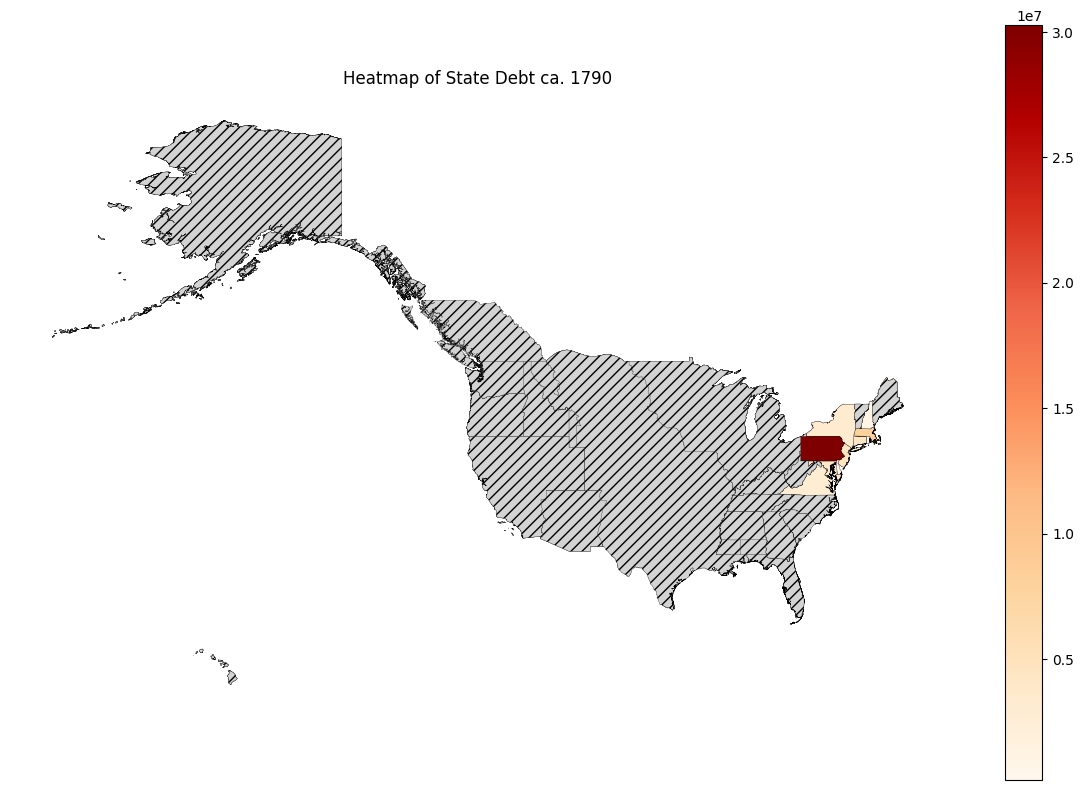

In [128]:
import us

states = gpd.read_file("data_raw/shapefiles/historicalstates")
states = states.rename(columns={'NAME': 'state'})
states['state'] = states['state'].astype(str).str.strip().str.title()

state_name_corrections = {
    "Alabama Territory": "Alabama", 
    "Alaska Department": "Alaska",
    "Alaska District": "Alaska",
    "Alaska Territory": "Alaska",
    "Arizona Territory": "Arizona",
    "Arkansas Territory": "Arkansas",
    "Colorado Territory": "Colorado",
    "Florida Territory": "Florida",
    "Florida Unorg. Ft": "Florida",
    "Hawaii Annexation": "Hawaii",
    "Hawaii Territory": "Hawaii",
    "Idaho Territory": 'Idaho',
    "Illinois Territory": "Illinois",
    "Indiana Territory": "Indiana",
    "Iowa Territory": "Iowa",
    "Kansas Territory": "Kansas", 
    "Louisiana Territory": "Louisiana Purchase",
    "Michigan Territory": "Michigan",
    "Minnesota Territory": "Minnesota",
    "Mississippi Terr.": "Mississippi",
    "Missouri Territory": "Missouri",
    "Montana Territory": "Montana",
    "Nebraska Territory": "Nebraska",
    "Nevada Territory": "Nevada",
    "New Mexico Territory": "New Mexico",
    "Oklahoma Territory": "Oklahoma",
    "Oregon Country": "Oregon",
    "Oregon Territory": "Oregon",
    "Oregon Unorg. Ft": "Oregon",
    "Orleans Territory": "Louisiana",
    "Southwest Territory": "Tennessee",
    "Texas Republic": "Texas",
    "Utah Territory": "Utah Territory",
    "Vermont Republic": "Vermont",
    "Washington Territory": "Washington",
    "Wisc. Terr. De Facto": "Wisconsin",
    "Wisconsin Territory": "Wisconsin",
    "Wyoming Territory": "Wyoming"
}

states['state'] = states['state'].replace(state_name_corrections)

def merge_territory(states, group, name):
    geom = states[states['state'].isin(group)].unary_union
    row = gpd.GeoDataFrame({'state': [name], 'geometry': [geom]}, crs=states.crs)
    states = states[~states['state'].isin(group)]
    return pd.concat([states, row], ignore_index=True)

states = merge_territory(states, ['North Dakota', 'South Dakota', 'Montana', 'Wyoming'], 'Dakota Territory')
states = merge_territory(states, ['Arizona', 'New Mexico'], 'Gadsden Purchase')
states = merge_territory(states, ['Louisiana', 'Arkansas', 'Missouri', 'Iowa', 'Oklahoma', 'Kansas', 'Nebraska', 
                                  'North Dakota', 'South Dakota', 'Minnesota', 'Montana', 'Wyoming', 'Colorado', 
                                  'New Mexico', 'Texas'], 'Louisiana Purchase')
states = merge_territory(states, ['California', 'Nevada', 'Utah', 'Arizona', 'New Mexico', 'Colorado', 'Wyoming'], 'Mexican Cession')
states = merge_territory(states, ['Ohio', 'Indiana', 'Illinois', 'Michigan', 'Wisconsin'], 'Northwest Territory')


df = pd.read_csv("cleaning_CD/pre1790/data/agg_debt_david.csv", header=0)
df.columns = df.columns.str.strip()

abbr_to_full = {
    'Ct': 'Connecticut',
    'CT': 'Connecticut',
    'De': 'Delaware',
    'DE': 'Delaware',
    'Ma': 'Massachusetts',
    'MA': 'Massachusetts',
    'Md': 'Maryland',
    'MD': 'Maryland',
    'Nh': 'New Hampshire',
    'NH': 'New Hampshire',
    'Nj': 'New Jersey',
    'NJ': 'New Jersey',
    'Ny': 'New York',
    'NY': 'New York',
    'Pa': 'Pennsylvania',
    'PA': 'Pennsylvania',
    'Ri': 'Rhode Island',
    'RI': 'Rhode Island',
    'Va': 'Virginia',
    'VA': 'Virginia',
    'Al': 'Alabama',
    'AL': 'Alabama',
    'AK': 'Alaska',
    'Ak': 'Alaska',
    'AZ': 'Arizona',
    'Az': 'Arizona',
    'AR': 'Arkansas',
    'Ar': 'Arkansas',
    'CA': 'California',
    'Ca': 'California',
    'CO': 'Colorado',
    'Co': 'Colorado',
    'DC': 'District of Columbia',
    'Dc': 'District of Columbia',
    'FL': 'Florida',
    'Fl': 'Florida',
    'GA': 'Georgia',
    'Ga': 'Georgia',
    'HI': 'Hawaii',
    'Hi': 'Hawaii',
    'ID': 'Idaho',
    'Id': 'Idaho',
    'IL': 'Illinois',
    'Il': 'Illinois',
    'IN': 'Indiana',
    'In': 'Indiana',
    'IA': 'Iowa',
    'Ia': 'Iowa',
    'KA': 'Kansas',
    'Ka': 'Kansas',
    'KY': 'Kentucky',
    'Ky': 'Kentucky',
    'LA': 'Louisiana',
    'La': 'Louisiana',
    'ME': 'Maine',
    'Me': 'Maine',
    'MI': 'Michigan',
    'Mi': 'Michigan',
    'MN': 'Minnesota',
    'Mn': 'Minnesota',
    'Ms': 'Mississippi',
    'MS': 'Mississippi',
    'Mo': 'Missouri',
    'MO': 'Missouri',
    'Mt': 'Montana',
    'MT': 'Montana',
    'NE': 'Nebraska',
    'Ne': 'Nebraska',
    'NV': 'Nevada',
    'Nv': 'Nevada',
    'Nc': 'North Carolina',
    'NC': 'North Carolina',
    'ND': 'North Dakota',
    'Nd': 'North Dakota',
    'OH': 'Ohio',
    'Oh': 'Ohio',
    'Ok': 'Oklahoma',
    'OK': 'Oklahoma',
    'OR': 'Oregon',
    'Or': 'Oregon',
    'Sc': 'South Carolina',
    'SC': 'South Carolina',
    'SD': 'South Dakota',
    'Sd': 'South Dakota',
    'Tn': 'Tennessee',
    'TN': 'Tennessee',
    'TX': 'Texas',
    'Tx': 'Texas',
    'Ut': 'Utah',
    'UT': 'Utah',
    'VT': 'Vermont',
    'Vt': 'Vermont',
    'WA': 'Washington',
    'Wa': 'Washington',
    'WV': 'West Virginia',
    'Wv': 'West Virginia',
    'WI': 'Wisconsin',
    'Wi': 'Wisconsin',
    'WY': 'Wyoming',
    'Wy': 'Wyoming',
}

state_col = "state"
amount_col = "amount | dollars"


df_map = df[[state_col, amount_col]].copy()
df_map['state'] = df_map['state'].astype(str).str.strip().str.title()

df_map['state'] = df_map['state'].replace(abbr_to_full)

df_map = df_map[df_map['state'].notna()]
df_map = df_map[df_map['state'].str.lower() != 'nan']
df_map[amount_col] = pd.to_numeric(df_map[amount_col], errors='coerce')
df_map = df_map.dropna(subset=[amount_col])

df_agg = df_map.groupby('state')[amount_col].sum().reset_index()

df_agg = df_agg.rename(columns={amount_col: 'amount'})
gdf = states.merge(df_agg, on='state', how='left')

gdf = gpd.GeoDataFrame(gdf, geometry='geometry')
gdf = gdf[gdf['geometry'].notnull()]
gdf = gdf[gdf['geometry'].apply(lambda g: g.is_valid and not g.is_empty)]

if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326", allow_override=True)

minx, miny, maxx, maxy = gdf.total_bounds
ax = gdf.plot(
    column='amount',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.2,
    figsize=(12, 8),
    missing_kwds={
        'color': 'lightgrey',
        'label': 'No data',
        'hatch': '///'
    }
)

ax.set_aspect(1 / np.cos(np.deg2rad((miny + maxy) / 2)))
plt.title("Heatmap of State Debt ca. 1790")
plt.axis('off')
plt.tight_layout()
plt.show()